# Chapter IV — Side-Loaded Plate (Missing Data / Subregion)

This notebook runs inverse identification using **only measurement data from a subregion** of the plate domain.

Configuration mirrors the legacy script intent:
- FEM-backed measurements (`source=fem`)
- Displacement measurements
- Subregion: `[0.1, 0.6, 0.1, 0.6]`
- Stress integral constraint enabled
- Stress boundary condition disabled

In [1]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt

from phd.config import load_config
import phd.models.cm.side_loaded_plate as slp
from phd.plot import get_current_config as plt_cfg, book_config
from phd.plot.plot_cm import plot_DIC_region

book_config.set_as_current()
page_width = plt_cfg().page_width

save_fig = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (missing pyproject.toml).")


PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "01_side_loaded_plate"
IMAGE_DIR = CHAPTER_DIR / "images"
PDF_DIR = IMAGE_DIR / "pdf"
PGF_DIR = IMAGE_DIR / "pgf"
VIDEO_DIR = CHAPTER_DIR / "videos"

for directory in [IMAGE_DIR, PDF_DIR, PGF_DIR, VIDEO_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



Project root: /home/r2d2/code/PhD


In [2]:
def build_missing_data_cfg(seed: int = 0):
    cfg = load_config("side_loaded_plate")

    cfg.seed = seed
    cfg.task.type = "inverse"

    cfg.model.net_type = "SPINN"
    cfg.model.formulation = "mixed"
    cfg.model.architecture.n_hidden = 3
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32
    cfg.model.architecture.mlp_type = "modified_mlp"

    cfg.problem.material.law = "isotropic"
    cfg.problem.geometry.length = 100.0  # selects 100x100mm FEM dataset
    cfg.problem.loading.m = 0.3
    cfg.problem.loading.b = 50.0

    cfg.training.n_iter = 40000
    cfg.training.lr = 1e-3
    cfg.training.lr_decay = ["warmup cosine", 1e-4, 5e-3, 1000, 30000, 1e-4]
    cfg.training.log_every = 100
    cfg.training.num_domain = 150**2
    cfg.training.coord_normalization = True
    cfg.training.stress_integral = True
    cfg.training.stress_bc = False
    cfg.training.loss_normalization.scheme = "grad_norm"
    cfg.training.loss_weights = [1.0] * 5 + [1e2] * 2 + [1.0]  # higher weight on measurement losses

    cfg.task.inverse.measurements.source = "fem"
    cfg.task.inverse.measurements.type = "displacement"
    cfg.task.inverse.measurements.n_observations.x = 40
    cfg.task.inverse.measurements.n_observations.y = 40
    cfg.task.inverse.measurements.dic.region = [0.1, 0.6, 0.1, 0.6]
    cfg.task.inverse.measurements.noise_ratio = 1e-4

    cfg.problem.log_fields = ["Ux", "Uy", "Sxx", "Syy", "Sxy"]

    cfg.results.base_dir = str(PROJECT_ROOT / "results")
    cfg.results.experiment_name = "missing_data_subregion"
    cfg.results.save_on_disk = True

    return cfg


cfg_preview = build_missing_data_cfg(seed=0)
print(f"Geometry length: {cfg_preview.problem.geometry.length}")
print(f"Measurements: {cfg_preview.task.inverse.measurements.type}")
print(f"Region: {list(cfg_preview.task.inverse.measurements.dic.region)}")

Geometry length: 100.0
Measurements: displacement
Region: [0.1, 0.6, 0.1, 0.6]


In [3]:
# Run or load
run_mode = "load"  # "run" or "load"
run_name = "missing_data_subregion_2"

if run_mode == "run":
    cfg = build_missing_data_cfg(seed=0)
    results = slp.train(cfg)
    run_dir = slp.save_run_data(results, run_name=run_name, base_dir=cfg.results.base_dir)
else:
    results = slp.load_run(run_name, base_dir=PROJECT_ROOT / "results")
    run_dir = Path(results["run_dir"])

print(f"Run mode: {run_mode}")
print(f"Run dir: {run_dir}")

runtime = results.get("runtime_metrics", {})
if runtime:
    print(f"Elapsed time [s]: {runtime.get('elapsed_time', float('nan')):.2f}")
    print(f"Iterations/s: {runtime.get('iterations_per_sec', float('nan')):.2f}")

Run mode: load
Run dir: /home/r2d2/code/PhD/results/side_loaded_plate/missing_data_subregion_2
Elapsed time [s]: 182.25
Iterations/s: 219.47


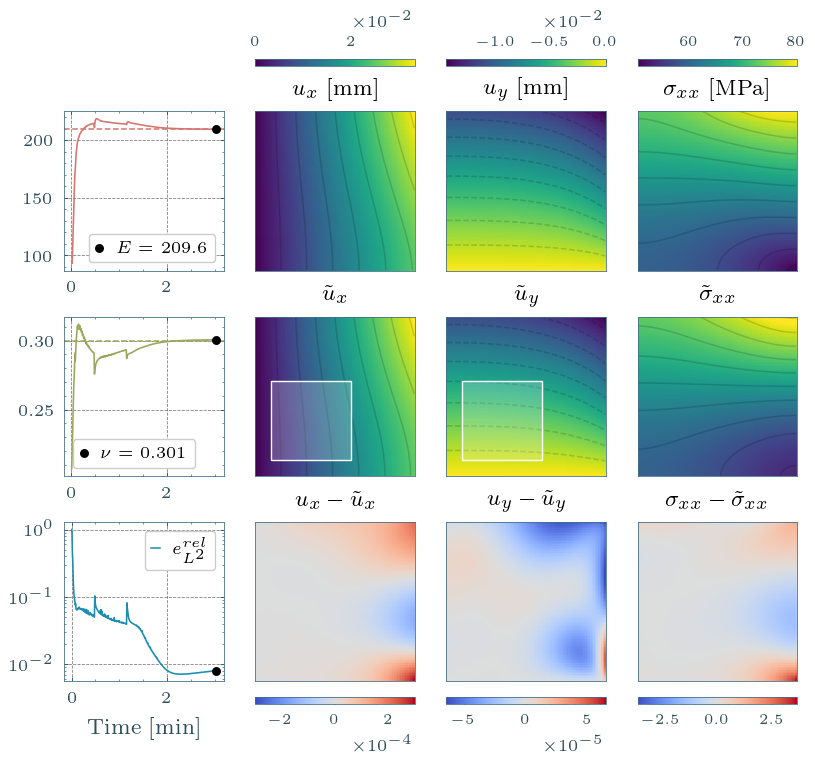

Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/missing_data_subregion_results.png
Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/pdf/missing_data_subregion_results.pdf


In [4]:
# Plot and save results
fig, artists = slp.plot_results(
    results,
    iteration=-1,
    step_type="time",
    time_unit="min",
    fields=["Ux", "Uy", "Sxx"],
    plot_contours=True,
    dpi=200,
    show_metrics=True,
    show_residual=True,
    show_iter=False,
    metrics=["L2 Error"],
    field_units={"Ux": "mm", "Uy": "mm", "Sxx": "MPa"},
)

plot_DIC_region(artists, results["config"], fields=("Ux", "Uy"), edgecolor="white", facecolor=(1, 1, 1, 0.2), linewidth=.5, add_points=False, point_kwargs={"s": 0.05, "color": "black", "alpha": 0.5})

plt.show()

if save_fig:
    figure_name = "missing_data_subregion_results"
    fig.savefig(IMAGE_DIR / f"{figure_name}.png", bbox_inches="tight", dpi=300)
    fig.savefig(PDF_DIR / f"{figure_name}.pdf", bbox_inches="tight")
    print(f"Saved: {IMAGE_DIR / (figure_name + '.png')}")
    print(f"Saved: {PDF_DIR / (figure_name + '.pdf')}")

In [8]:
# === Generate Animation for Current Missing-Data Run ===
from IPython.display import Video
from phd.plot.plot_cm import subsample_frames, plot_DIC_region
from importlib import reload
reload(plt)
reload(slp)

video_path = VIDEO_DIR / "missing_data_subregion_animation.mp4"
print("Generating animation preview...")
field_cmap = plt.get_cmap("viridis", 15)  # Discrete viridis with 10 steps

# Build artists at iteration 0 for animation playback
fig_anim, artists_anim = slp.plot_results(
    results,
    iteration=0,
    dpi=200,
    step_type="time",
    time_unit="min",
    show_iter=True,
    fields=["Ux", "Uy", "Sxx"],
    field_cmap=field_cmap,
    # plot_contours=True,
    show_metrics=True,
    show_residual=True,
    metrics=["L2 Error"],
    field_units={"Ux": "mm", "Uy": "mm", "Sxx": "MPa"},
)

# Overlay DIC region on the animated prediction panels
plot_DIC_region(
    artists_anim,
    results["config"],
    fields=("Ux", "Uy"),
    edgecolor="white", 
    facecolor=(1, 1, 1, 0.2),
    linewidth=0.5,
    add_points=False,
    point_kwargs={"s": 0.05, "color": "black", "alpha": 0.5},
)

# More temporal detail at the beginning, more aggressive subsampling later
n_frames = len(artists_anim["steps"])
frame_indices = subsample_frames(n_frames, factors=[1, 3, 5, 7, 9, 9, 9, 9])

# Preview in notebook without writing the MP4 to disk
slp.animate(fig_anim, artists_anim, video_path, fps=10, frame_indices=frame_indices, preview=True)

# Uncomment to save and display the MP4:
slp.animate(fig_anim, artists_anim, video_path, fps=10, frame_indices=frame_indices)
# Video(video_path, embed=True, html_attributes="controls loop autoplay")

Generating animation preview...
Animation preview:
  Total available frames: 400
  Selected frames: 110
  FPS: 10
  Duration: 11.0s
Animation saved to /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/videos/missing_data_subregion_animation.mp4 (110 frames, 11.0s)


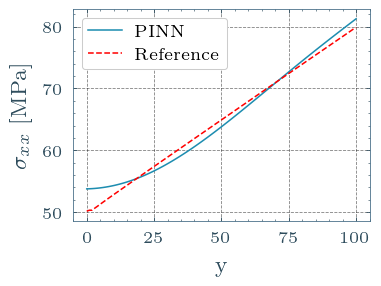

Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/missing_data_subregion_Sxx_profile.png
Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/pgf/missing_data_subregion_Sxx_profile.pgf


In [6]:
# Sxx vs reference on the right edge (legacy-style)
field_data = slp.extract_fields_at_iterations(
    results,
    iterations=[-1],
    field_names=["Sxx"],
)

Xmesh = field_data["X"]
Ymesh = field_data["Y"]
Sxx_final = field_data["pred"]["Sxx"][-1]
Sxx_ref = field_data["exact"]["Sxx"]

fig, ax = plt.subplots(figsize=(page_width * 0.4, page_width * 0.3), dpi=200, constrained_layout=True)
ax.plot(Ymesh[-1, :], Sxx_final[-1, :], label="PINN")
ax.plot(Ymesh[-1, :], Sxx_ref[-1, :], "r--", label="Reference")
ax.set_xlabel("y")
ax.set_ylabel(r"$\sigma_{xx}$ [MPa]")
# ax.set_title("Right edge profile (x = max)")
ax.legend(fontsize=plt_cfg().axes_font_size).get_frame().set_linewidth(plt_cfg().scale)
plt.show()

if save_fig:
    figure_name = "missing_data_subregion_Sxx_profile"
    fig.savefig(IMAGE_DIR / f"{figure_name}.png", bbox_inches="tight", dpi=300)
    fig.savefig(PGF_DIR / f"{figure_name}.pgf", bbox_inches="tight")
    print(f"Saved: {IMAGE_DIR / (figure_name + '.png')}")
    print(f"Saved: {PGF_DIR / (figure_name + '.pgf')}")

In [25]:
from IPython.display import display
from phd.io import save_df_to_latex
import json
import numpy as np
import pandas as pd

VFM_JSON_PATH = CHAPTER_DIR / "tables" / "VFM_missing_data.json"
VFM_TABLE_TEX_PATH = CHAPTER_DIR / "tables" / "vfm_vs_spinn_missing_data.tex"

E_REF = 210.0
NU_REF = 0.3000

if not VFM_JSON_PATH.exists():
    raise FileNotFoundError(f"VFM JSON not found: {VFM_JSON_PATH}")

with open(VFM_JSON_PATH, "r") as f:
    vfm_data = json.load(f)

vfm_block = vfm_data["vfm_missing_data"]
vfm_E = float(vfm_block["E_GPa"]["mean"])
vfm_nu = float(vfm_block["nu"]["mean"])

E_history = np.array(results["callbacks"]["variable_value"].history)[:, 1]
nu_history = np.array(results["callbacks"]["variable_value"].history)[:, 2]

spinn_E = np.mean(E_history[-10:]) / 1e3  # convert from MPa to GPa
spinn_nu = np.mean(nu_history[-10:]) # average over last 10 iterations

rows = [
    {"Model": "Reference", "E (GPa)": E_REF, "ν": NU_REF},
    {"Model": "VFM*", "E (GPa)": vfm_E, "ν": vfm_nu},
    {"Model": "SPINN", "E (GPa)": float(spinn_E), "ν": float(spinn_nu)},
]

df_vfm_comp = pd.DataFrame(rows)
df_vfm_comp["E — Error (%)"] = np.where(
    df_vfm_comp["Model"].eq("Reference"),
    np.nan,
    np.abs((df_vfm_comp["E (GPa)"] - E_REF) / E_REF) * 100.0,
)
df_vfm_comp["ν — Error (%)"] = np.where(
    df_vfm_comp["Model"].eq("Reference"),
    np.nan,
    np.abs((df_vfm_comp["ν"] - NU_REF) / NU_REF) * 100.0,
)

display(
    df_vfm_comp.style
    .format({
        "E (GPa)": "{:.2f}",
        "ν": "{:.4f}",
        "E — Error (%)": "{:.2f}",
        "ν — Error (%)": "{:.2f}",
    })
    .set_properties(subset=["Model"], **{"text-align": "left"})
)

save_table = True
if save_table:
    formatters = {
        "E (GPa)": "{:.2f}",
        "ν": "{:.4f}",
        "E — Error (%)": "{:.2f}",
        "ν — Error (%)": "{:.2f}",
    }
    save_df_to_latex(df_vfm_comp, str(VFM_TABLE_TEX_PATH), formatters=formatters)
    print(f"Saved: {VFM_TABLE_TEX_PATH}")

,Model,E (GPa),ν,E — Error (%),ν — Error (%)
0,Reference,210.00,0.3000,nan,nan
1,VFM*,226.84,0.2870,8.02,4.33
2,SPINN,209.47,0.3007,0.25,0.23


Saved LaTeX table to /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/tables/vfm_vs_spinn_missing_data.tex
Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/tables/vfm_vs_spinn_missing_data.tex
